# 简介

之前的章节介绍了基于策略梯度的算法 REINFORCE、Actor-Critic 以及两个改进算法——TRPO 和 PPO。
**这类算法有一个共同的特点**：
- 它们都是在线策略算法，这意味着它们的样本效率（sample efficiency）比较低。


我们回忆一下 DQN 算法，DQN 算法直接估计**最优函数 Q**：
- 可以做到离线策略学习，**但是它只能处理动作空间有限的环境，这是因为它需要从所有动作中挑选一个值最大的动作。** 
- 如果动作个数是无限的，**虽然我们可以像 Double DQN 算法，将动作空间离散化，但这比较粗糙，无法精细控制。**


#### 那有没有办法可以用类似的思想来处理 动作空间无限的环境 并且使用的是 离线策略 算法呢？
- 本章要讲解的深度确定性策略梯度（deep deterministic policy gradient，DDPG）算法就是如此，它构造一个确定性策略，用梯度上升的方法来最大化Q值

**DDPG 也属于一种 Actor-Critic 算法** 。我们之前学习的 REINFORCE、TRPO 和 PPO 学习随机性策略，而本章的 DDPG 则学习一个确定性策略。

# DDPG 算法

- 之前我们学习的策略是**随机性的**，可以表示为a ~ $π_θ{(·|s)}$；

- 而如果策略是**确定性的**，则可以记为$a = u_θ{(s)}$。

与策略梯度定理类似，我们可以推导出**确定性策略梯度定理**（deterministic policy gradient theorem）：


In [1]:
from IPython.display import Image

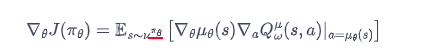

In [2]:
Image(filename='./image/ddpg_dingli.png')

- $π_β$是用来收集数据的行为策略

**我们可以这样理解这个定理**：

- 假设现在已经有函数Q，给定一个状态s，但由于现在动作空间是无限的，无法通过遍历所有动作来得到Q值最大的动作，因此我们想用策略$u$找到使Q(s,a)值最大的动作a，即$u(s) = argmax_a{Q(s,a)}$。

- 此时，**函数Q就是 Critic，策略$u$就是 Actor** ，这是一个 Actor-Critic 的框架，如下图所示。

#### 那如何得到这个$u$呢？
- 首先用Q对$u_θ$求导$▽_θ{Q(s,u_θ(s))}$，其中会用到梯度的链式法则
   - 先对a求导，再对θ求导。
- 然后通过梯度上升的方法来最大化函数Q，得到Q值最大的动作。

#### 下图 DDPG 中的 Actor 网络和 Critic 网络，以倒立摆环境为例

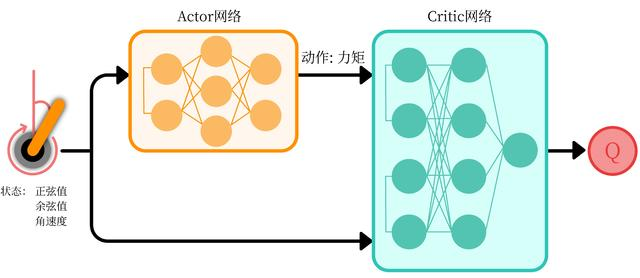

In [3]:
Image(filename='./image/ddpg_ac.png',width=600)

**下面我们来看一下 DDPG 算法的细节。**

DDPG 要用到个神经网络，其中 Actor 和 Critic 各用一个网络，此外它们都各自有一个目标网络。

至于为什么需要目标网络，读者可以去看 DQN 中的介绍。**DDPG 中 Actor 也需要目标网络因为目标网络也会被用来计算目标Q值。** 

**DDPG 中目标网络的更新与 DQN 中略有不同：**
- 在 DQN 中，每隔一段时间将网络直接复制给目标网络；
- 在 DDPG 中，目标网络的更新采取的是一种软更新的方式，即 **让目标网络缓慢更新，逐渐接近网络** 
   - 其公式为：$w^- ← τw + (1-τ)w^-$

   - 通常τ是一个比较小的数，当τ=1时，就和 DQN 的更新方式一致了即$w^-  = w$。而**目标网络$u$也使用这种软更新的方式。**

- 另外，由于函数Q存在Q值过高估计的问题，DDPG 采用了 Double DQN 中的技术来更新网络Q。
  - 但是，由于 DDPG 采用的是确定性策略，它本身的探索仍然十分有限。
    - 回忆一下 DQN 算法，它的探索主要由epsilon-贪婪策略的行为策略产生。
    - <font color='red'>同样作为一种离线策略的算法，DDPG 在行为策略上引入一个随机噪声$N$来进行探索。<font>

#### 我们来看一下 DDPG 的具体算法流程吧！



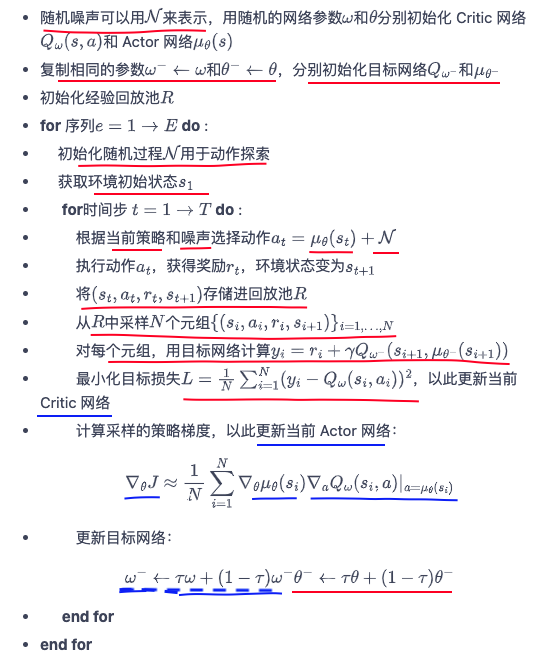

In [4]:
Image(filename='./image/ddpg-sche.png',width=600)

# DDPG 代码实践

In [6]:


import random
import gym
import numpy as np
from tqdm import tqdm
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


对于策略网络和价值网络，我们都采用只有一层隐藏层的神经网络。

- 策略网络的输出层用正切函数（y = tanhx）作为激活函数，这是因为正切函数的值域是[-1,1]，**方便按比例调整成环境可以接受的动作范围**。

在 DDPG 中处理的**是与连续动作交互的环境：**
- Q网络的**输入** 是: **状态和动作拼接后的向量**，
- Q网络的**输出** 是: 一个值，表示该状态、动作对的价值。

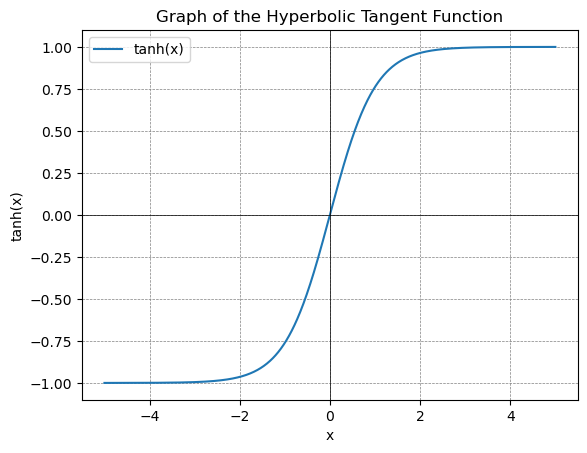

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 定义正切双曲函数
def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

# 生成 x 值
x = np.linspace(-5, 5, 1000)

# 计算 y 值
y = tanh(x)

# 绘制图形
plt.plot(x, y, label="tanh(x)")
plt.title("Graph of the Hyperbolic Tangent Function")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()

图形解释
运行上述代码后，你会看到一个平滑的 S 形曲线，具有以下特征：
- 对称性：曲线关于原点对称，即 tanh(−x)=−tanh(x)。
- 渐近线：当 x 趋向于正无穷时，tanhx 趋向于 1；当 x 趋向于负无穷时，tanhx 趋向于 -1。
- 零点：在 x=0 时，tanhx=0。
- 平滑性：曲线在所有点上都是平滑的，没有尖角或不连续点。


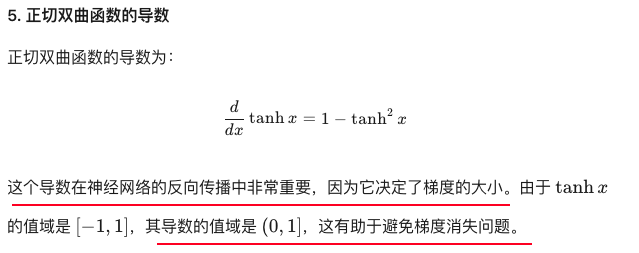

In [4]:
Image(filename='./image/tanh.png',width=600)

In [9]:
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)
        # action_bound是环境可以接受的动作最大值
        self.action_bound = action_bound  

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return torch.tanh(self.fc2(x)) * self.action_bound


class QValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        cat = torch.cat([x, a], dim=1) # 拼接状态和动作
        
        x = F.relu(self.fc1(cat))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)

#### 接下来是 DDPG 算法的主体部分

在用策略网络采取动作的时候，为了更好地探索，**我们向动作中加入高斯噪声**。在 DDPG 的原始论文中，添加的噪声符合奥恩斯坦-乌伦贝克（Ornstein-Uhlenbeck，**OU**）随机过程：

$△x_t = θ(u - x_{t-1}) + σW $

其中，
- $u$是均值，是长期均值，即过程的平衡点
- W是符合布朗运动的随机噪声，是标准布朗运动（Wiener 过程）
- θ 是均值回归速率，控制过程回归到均值的速度。
- σ 是波动率，控制随机扰动的强度。

<font color='red'>$可以看出，当x_{t-1}偏离均值时，x_t的值会向均值靠拢。$<font>

- **OU 随机过程** 的特点是 **在均值附近做出线性负反馈，并有额外的干扰项**。
- OU 随机过程是**与时间相关的**，适用于有惯性的系统。
- 在 DDPG 的实践中，不少地方仅使用正态分布的噪声。这里为了简单起见，同样使用正态分布的噪声，感兴趣的读者可以自行改为 OU 随机过程并观察效果。
    
### OU 随机过程的离散形式
在实际应用中，通常使用离散时间的 OU 随机过程。其离散形式可以表示为：
$x_{t+1}=x_t+θ(μ−x_t)Δt+σ\sqrt{Δt}ξ_t$

其中：
- Δt 是时间步长。
- ξt是标准正态分布的随机变量。


# OU 随机过程的 Python 实现

以下是一个简单的 Python 实现，用于生成 OU 随机过程的样本路径：

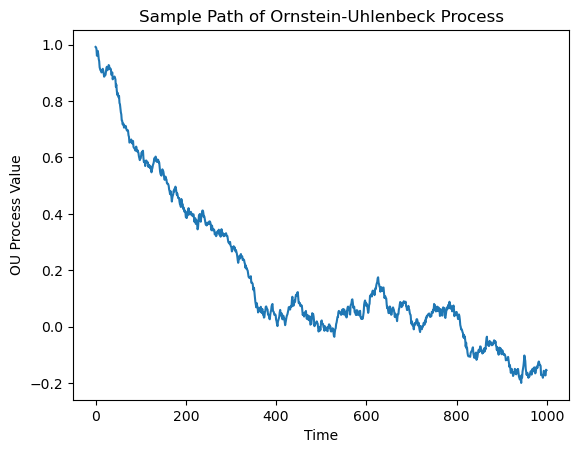

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class OrnsteinUhlenbeckProcess:
    def __init__(self, mu, theta, sigma, dt=1e-2, x0=None):
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.dt = dt
        self.x0 = x0
        self.x = x0 if x0 is not None else np.zeros_like(mu)

    def step(self):
        self.x += self.theta * (self.mu - self.x) * self.dt + self.sigma * np.sqrt(self.dt) * np.random.normal(size=np.shape(self.mu))
        return self.x

    def sample(self, n_steps):
        path = []
        for _ in range(n_steps):
            self.step()
            path.append(self.x.copy())
        return np.array(path)

# 参数设置
mu = 0.0
theta = 0.5
sigma = 0.1
dt = 0.01
x0 = 1.0

# 创建 OU 过程
ou_process = OrnsteinUhlenbeckProcess(mu, theta, sigma, dt, x0)

# 生成样本路径
n_steps = 1000
path = ou_process.sample(n_steps)

# 绘制路径
plt.plot(path)
plt.xlabel('Time')
plt.ylabel('OU Process Value')
plt.title('Sample Path of Ornstein-Uhlenbeck Process')
plt.show()

### OU 随机过程的特性
- 均值回归：OU 过程具有均值回归特性，即过程值会逐渐回归到长期均值 μ。
- 平稳性：在长期，OU 过程是平稳的，其均值和方差保持不变。
- 随机性：过程值受到随机扰动的影响，具有一定的波动性。
### OU 随机过程在强化学习中的应用
- 在强化学习中，OU 随机过程常用于探索策略，特别是在连续动作空间的任务中。
- 例如，在 DDPG 算法中，OU 随机过程用于为策略网络的输出添加噪声，从而实现探索。

<font color='red'>这种方法可以有效地平衡探索和利用，提高算法的性能。<font>
    
### 示例：DDPG 中的 OU 随机过程
    
以下是一个在 DDPG 算法中使用 OU 随机过程的示例：

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
print(np.__version__)

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.tanh(self.fc2(x))

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

class DDPG:
    def __init__(self, state_dim, action_dim, gamma, actor_lr, critic_lr):
        self.actor = Actor(state_dim, action_dim)
        self.critic = Critic(state_dim, action_dim)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.gamma = gamma
        self.ou_process = OrnsteinUhlenbeckProcess(mu=np.zeros(action_dim), theta=0.15, sigma=0.2)

    def select_action(self, state):
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        action = self.actor(state).detach().numpy().squeeze(0)
        noise = self.ou_process.step()
        return action + noise

# 示例使用
ddpg = DDPG(state_dim=4, action_dim=2, gamma=0.99, actor_lr=1e-4, critic_lr=1e-3)
state = np.array([1.0, 2.0, 3.0, 4.0])
action = ddpg.select_action(state)
print("Selected Action:", action)

1.26.4
Selected Action: [0.47344238 0.30393181]


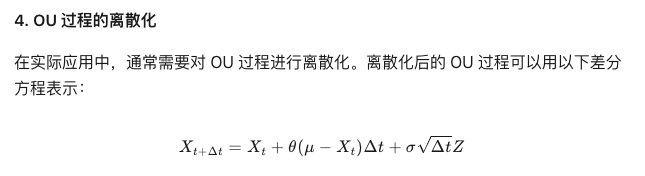

In [6]:
Image(filename='./image/OU.png',width=600)

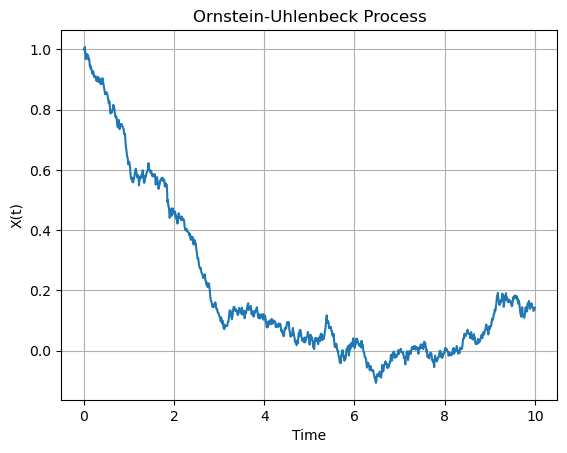

In [10]:
'''以下是一个使用 Python 和 NumPy 模拟 OU 过程的示例代码：'''
import numpy as np
import matplotlib.pyplot as plt

# OU 过程的参数
theta = 0.5  # 均值回归速率
mu = 0.0     # 长期均值
sigma = 0.1  # 波动率
dt = 0.01    # 时间步长
T = 10       # 总时间
num_steps = int(T / dt)

# 初始化
X = np.zeros(num_steps)
X[0] = 1.0  # 初始值

# 模拟 OU 过程
for t in range(1, num_steps):
    X[t] = X[t-1] + theta * (mu - X[t-1]) * dt + sigma * np.sqrt(dt) * np.random.normal()

# 绘制结果
plt.plot(np.linspace(0, T, num_steps), X)
plt.title("Ornstein-Uhlenbeck Process")
plt.xlabel("Time")
plt.ylabel("X(t)")
plt.grid(True)
plt.show()

# DDPG算法
- 在 DDPG 的实践中，不少地方仅使用正态分布的噪声。
- 这里为了简单起见，同样使用正态分布的噪声，感兴趣的读者可以自行改为 OU 随机过程并观察效果。

In [ ]:

class DDPG:
    def __init__(self,state_dim,hidden_dim,action_dim,action_bound,sigma,actor_lr,critic_lr,tau,gamma,device):
        self.actor = PolicyNet(state_dim,hidden_dim,action_dim,action_bound).to(device)
        self.critic = QValueNet(state_dim,hidden_dim,action_dim).to(device)
        
        # 目标网络
        self.target_actor = PolicyNet(state_dim,hidden_dim,action_dim,action_bound).to(device)
        self.target_critic = QValueNet(state_dim,hidden_dim,action_dim).to(device)
        
        # 初始化 目标价值网络 并设置和价值网络 相同的参数
        self.target_critic.load_state_dict(self.critic.state_dict())
        # 初始化 目标策略网络 并设置和策略网络 相同的参数
        self.target_actor.load_state_dict(self.actor.state_dict())
        
        self.actor_optimizer = torch.optim.Adam(self.actor.paramters(),lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.paramters(),lr=critic_lr)
        
        self.gamma = gamma
        self.sigma = sigma # 高斯噪声的标准差，均值直接设置为0
        self.tau = tau # 一个介于 0 和 1 之间的超参数，表示更新的步长。较小的 tau 值意味着目标网络的参数更新得更慢，更接近主网络的参数。
        self.action_dim = action_dim
        self.device = device
        
    def take_action(self,state):
        state = torch.tensor([state],dtype= torch.float).to(self.device)
        action = self.actor(state).item()
        # 给动作添加噪声
        action = action + self.sigma * np.random.randn(self.action_dim)
        reutrn action 
        
    # “软更新”（soft update）它通过将目标网络的参数逐渐向主网络（net）的参数靠拢，而不是直接复制主网络的参数。
    # self.tau ：一个介于 0 和 1 之间的超参数，表示更新的步长。较小的 tau 值意味着目标网络的参数更新得更慢，更接近主网络的参数。
    def soft_update(self,net,target_net):
        for param_target,param in zip(target_net.paramters(),net.paramters()):
            # tau 的值通常很小（例如 0.01 或 0.001），以确保目标网络的参数更新得比较平滑。
            
            # param_target.data * (1.0 - self.tau)：保留目标网络参数的一部分（大部分）。
            # param.data * self.tau：加上主网络参数的一部分（小部分）。
            
            # 这种更新方式确保目标网络的参数不会突然变化，而是平滑地向主网络的参数靠拢。
            
            # 在较新的 PyTorch 版本中，data 属性已经被弃用，推荐直接使用张量本身进行操作。
            # param_target.data.copy_(param_target.data * (1.0- self.tau) + param.data * self.tau)
            param_target.copy_(param_target.data * (1.0- self.tau) + param.data * self.tau)
            
    def upadte(self,transition_dict):
        states = torch.tensor(transition_dict['states'],dtype = torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'],dtype=torch.float).view(-1,1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1,1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],dtype=torch.float).view(-1,1).to(self.device)
        
        # 计算下个状态的价值
        next_q_value = self.target_critic(next_states,self.target_actor(next_states))
        # 计算TD目标
        q_targets = rewards + self.gamma*next_q_value * (1-dones)
        
        critic_loss = torch.mean(F.mse_loss(self.critic(states,actions),q_targets))
        self.critic_optimizer.zero_grad()
        # 计算梯度
        critic_loss.backward()
        # 更新参数
        self.critic_optimizer.step()
        
        # 取负号是因为我们需要最大化 Q 值，而优化器默认是做最小化。因此，最大化 Q 值等价于最小化负的 Q 值
        actor_loss = -torch.mean(self.critic(states,self.actor(states)))
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        # 软更新
        self.soft_update(self.actor,self.target_actor)
        self.soft_update(self.critic,self.target_critic)
    

In [ ]:
actor_lr = 3e-4
critic_lr = 3e-3
num_episodes = 200
hidden_dim = 64
gamma = 0.98
tau = 0.005 # 软更新参数
buffer_size = 10000
minimal_size = 1000
batch_size = 64
sigma = 0.01 # 高斯高音标准差
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

env_name = 'Pendulum-v1'
env = gym.make(env_name)

random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)

replay_buffer = rl_utils.replay_buffer(buffer_size)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0] # 动作最大值
agent = DDPG(state_dim,hidden_dim,action_dim,action_bound,sigma,actor_lr,critic_lr,tau,gamma,device)

return_list = rl_utils.train_off_policy_agent(env,agent,num_episodes,replay_buffer,minimal_size,batch_size)


In [ ]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DDPG on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DDPG on {}'.format(env_name))
plt.show()

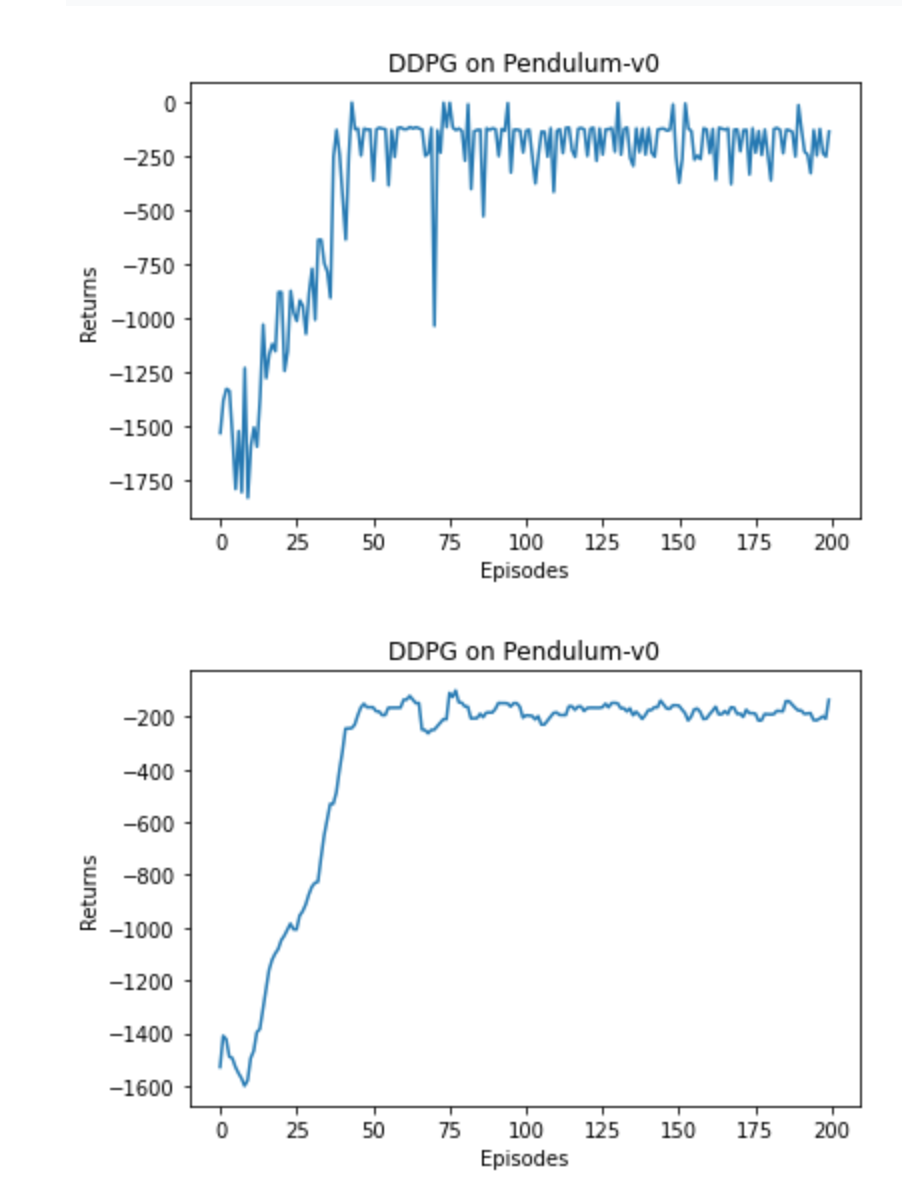

In [7]:
Image(filename='./image/ddpg_chart.png',width=600)

#### 可以发现 DDPG 在倒立摆环境中表现出很不错的效果，其学习速度非常快，并且不需要太多样本。

有兴趣的读者可以尝试自行调节超参数（例如用于探索的高斯噪声参数），观察训练结果的变化。

# 小结

本章讲解了深度确定性策略梯度算法（DDPG），**它是面向连续动作空间的深度确定性策略训练的典型算法。**

相比于它的先期工作，即确定性梯度算法（DPG），**DDPG 加入了目标网络和软更新的方法**，
- <font color='red'>这对深度模型构建的价值网络和策略网络的稳定学习起到了关键的作用。<font>

#### DDPG 算法也被引入了多智能体强化学习领域，催生了 MADDPG 算法

 ## 扩展阅读：确定性策略梯度定理的证明

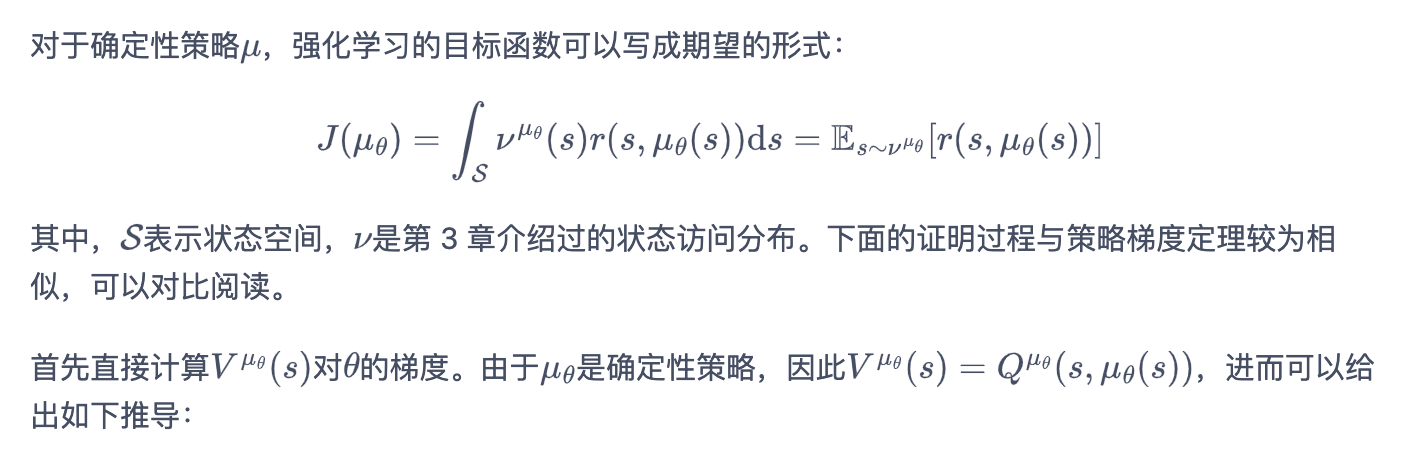

In [2]:
Image(filename='./image/ddpg_p_01.png',width=600)

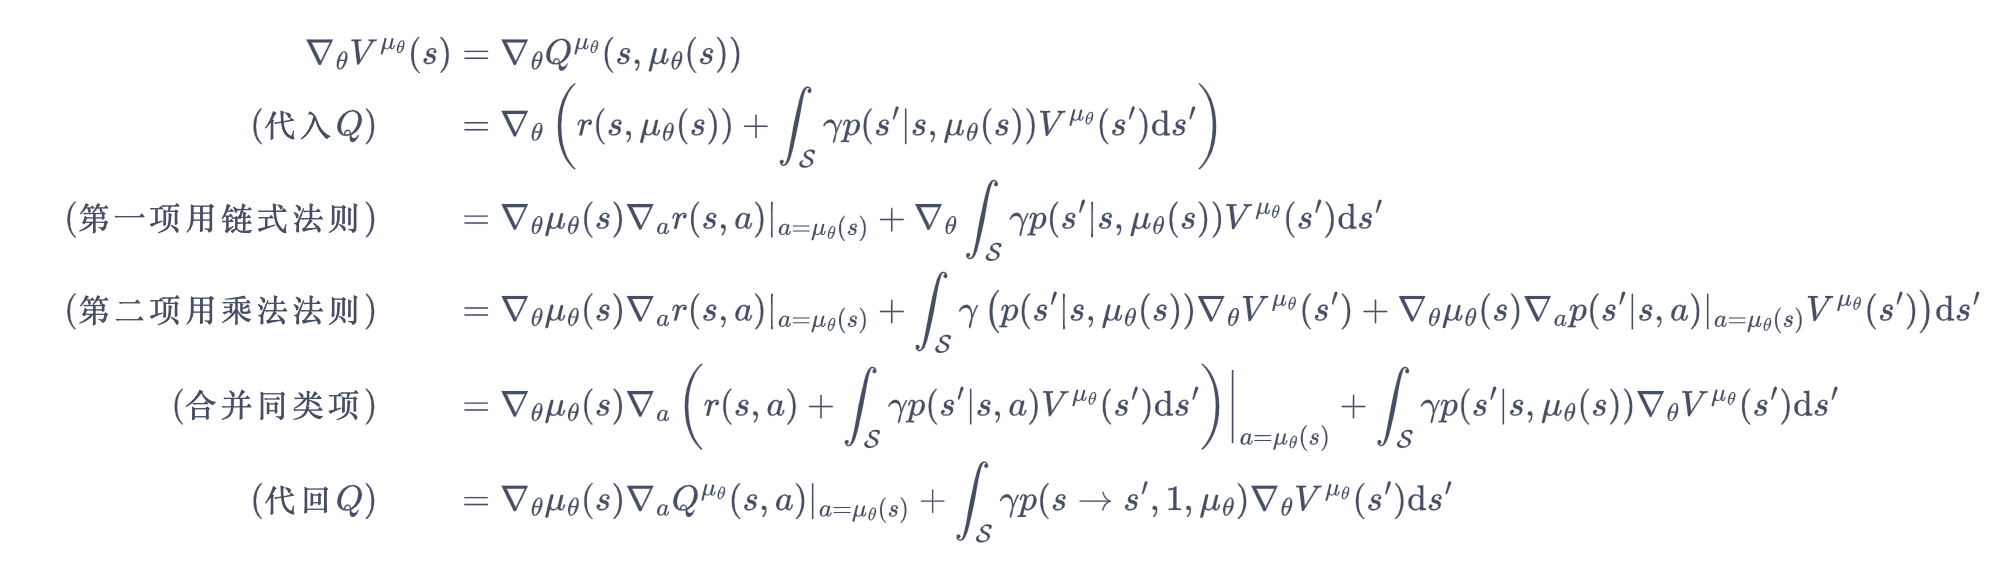

In [3]:
Image(filename='./image/ddpg_p_02.png',width=600)

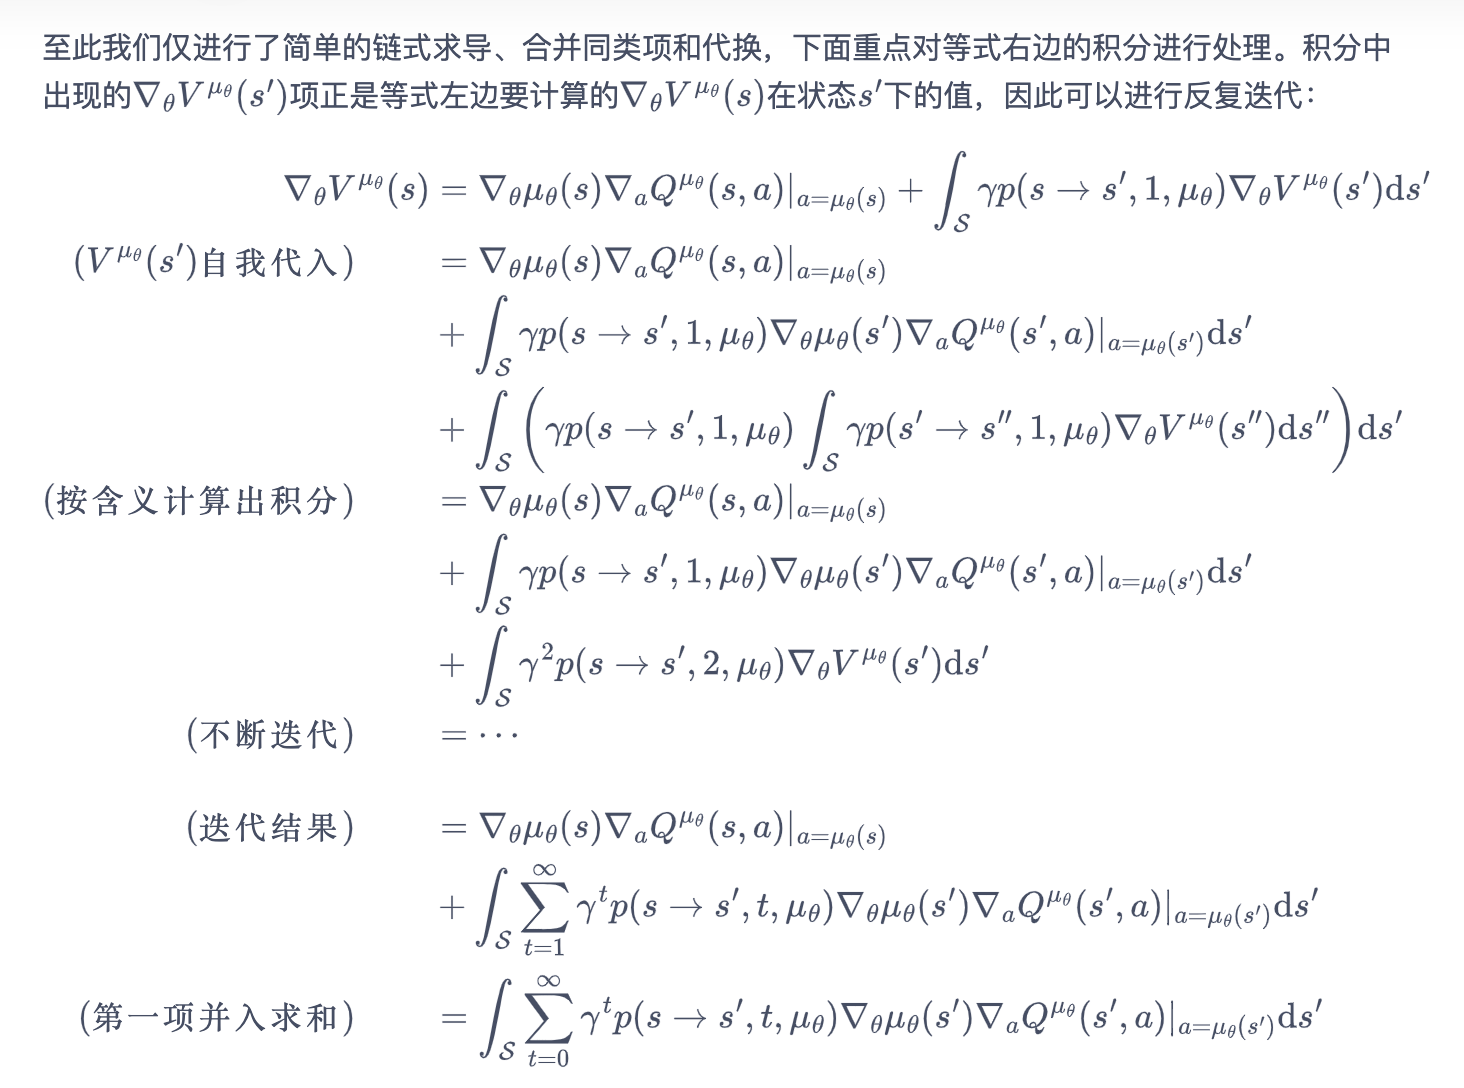

In [4]:
Image(filename='./image/ddpg_p_03.png',width=600)

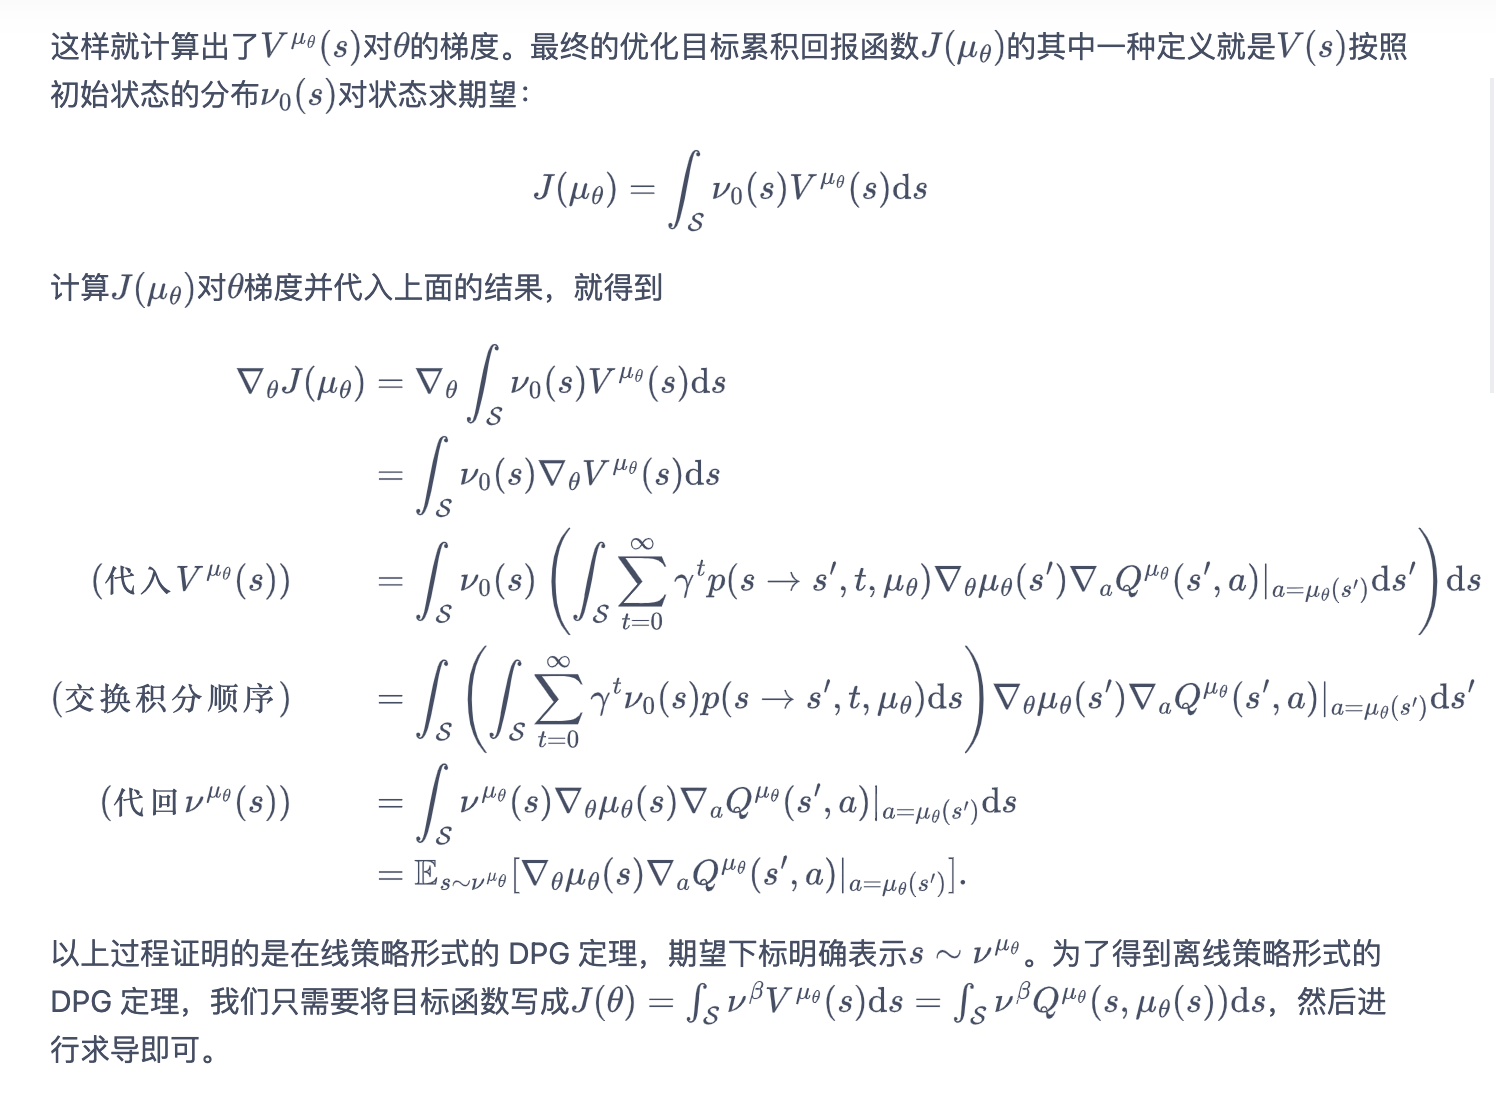

In [5]:
Image(filename='./image/ddpg_p_04.png',width=600)

# 参考文献
[1] SILVER D, LEVER G, HEESS N, et al. Deterministic policy gradient algorithms [C]// International conference on machine learning, PMLR, 2014: 387-395.

[2] LILLICRAP T P, HUNT J J, PRITZEL A, et al. Continuous control with deep reinforcement learning [C]// International conference on learning representation, 2016.

